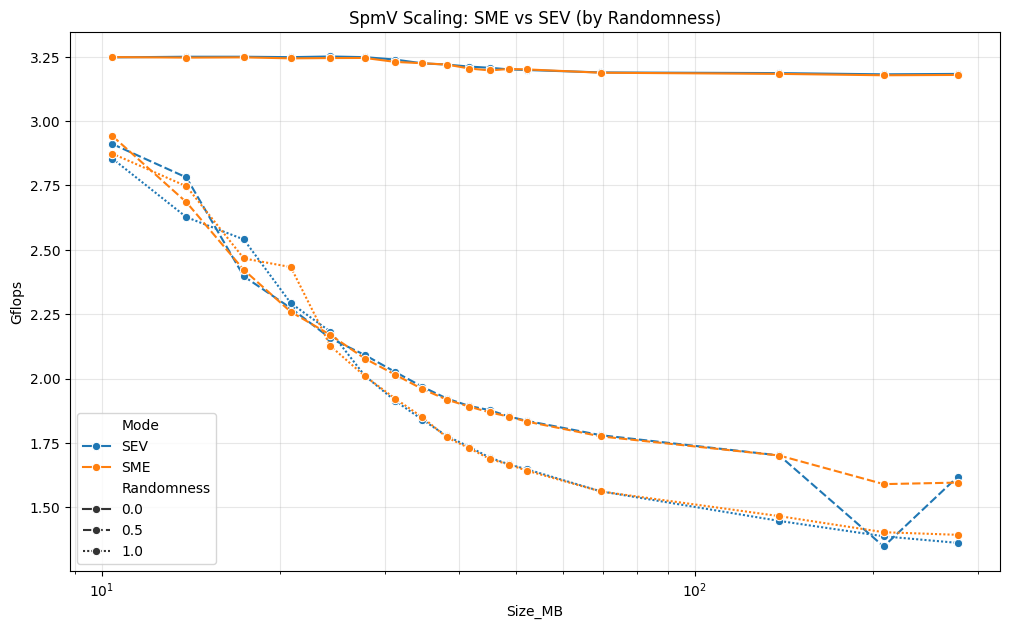

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Konfiguration
path_sme = '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260203_192748/summary.csv'
path_sev = '/home/mengelsl/MA-bench-framework/cachefit_testing/outputs/spmv_comparison_20260203_194143/summary.csv'
matrix_base_dir = './matrices' 

def get_mb(row):
    r_str = str(row['Randomness']).replace('.', '-')
    f_path = os.path.join(matrix_base_dir, f"{r_str}_N{int(row['N'])}.bin")
    return os.path.getsize(f_path) / (1024**2) if os.path.exists(f_path) else None

# 2. Daten laden & Vorbereiten
df_sme = pd.read_csv(path_sme)
df_sev = pd.read_csv(path_sev) 
df_sme['Mode'], df_sev['Mode'] = 'SME', 'SEV'

df_all = pd.concat([df_sme, df_sev])

# 3. Matrix-Größe berechnen
df_all['Size_MB'] = df_all.apply(get_mb, axis=1)

# 4. Aggregieren (Mittelwert über die Runs)
df_avg = df_all.groupby(['Mode', 'N', 'Randomness', 'Size_MB']).agg({'Gflops': 'mean'}).reset_index()

plt.figure(figsize=(12, 7))
# hue = Farbe (SME/SEV), style = Linienstil (Randomness)
sns.lineplot(data=df_avg, x='Size_MB', y='Gflops', hue='Mode', style='Randomness', marker='o')

plt.title('SpmV Scaling: SME vs SEV (by Randomness)')
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.xscale('log')
plt.show()

In [11]:
# 1. Daten in Spalten für SME und SEV umstrukturieren
df_pivot = df_avg.pivot(index=['N', 'Randomness', 'Size_MB'], columns='Mode', values='Gflops').reset_index()

# 2. Prozentualen Unterschied berechnen (SEV relativ zu SME)
# Formel: ((SEV / SME) - 1) * 100
df_pivot['Diff_%'] = (df_pivot['SEV'] / df_pivot['SME'] - 1) * 100

# 3. Tabelle nach Größe sortieren
df_pivot = df_pivot.sort_values(['Randomness', 'Size_MB'])

# 4. Schöne Formatierung für die Anzeige
pd.options.display.float_format = '{:,.3f}'.format
print("Vergleich SME vs. SEV (Werte in GFLOPS, Diff in %):")
display(df_pivot)

# Bonus: Kurze Zusammenfassung nach Randomness-Stufe
print("\nDurchschnittlicher Overhead pro Randomness-Stufe:")
print(df_pivot.groupby('Randomness')['Diff_%'].mean())

Vergleich SME vs. SEV (Werte in GFLOPS, Diff in %):


Mode,N,Randomness,Size_MB,SEV,SME,Diff_%
0,30000,0.000,10.414,3.247,3.248,-0.034
3,40000,0.000,13.886,3.250,3.246,0.105
6,50000,0.000,17.357,3.250,3.247,0.077
9,60000,0.000,20.828,3.248,3.244,0.143
12,70000,0.000,24.300,3.251,3.245,0.188
15,80000,0.000,27.771,3.248,3.245,0.096
18,90000,0.000,31.242,3.239,3.230,0.281
21,100000,0.000,34.714,3.224,3.225,-0.011
24,110000,0.000,38.185,3.219,3.220,-0.009
27,120000,0.000,41.657,3.212,3.204,0.235



Durchschnittlicher Overhead pro Randomness-Stufe:
Randomness
0.000    0.096
0.500   -0.550
1.000   -0.554
Name: Diff_%, dtype: float64
